<a href="https://colab.research.google.com/github/Tejas325-creator/regional-sales-performance-dashboard/blob/main/COMPUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile
import os

# 1️⃣ Upload the zip file from your laptop
uploaded = files.upload()  # select CATVSDOG.zip

# 2️⃣ Unzip the dataset
zip_path = "dataset cat dog.zip"
extract_path = "dataset cat dog"  # folder where data will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3️⃣ Verify the extraction
print("Dataset extracted to:", extract_path)
print("Subfolders/classes:", os.listdir(extract_path))


Saving dataset cat dog.zip to dataset cat dog.zip
Dataset extracted to: dataset cat dog
Subfolders/classes: ['dataset cat dog']


In [ ]:
import cv2
import os

def process_images_in_directory(directory, image_extensions=['.jpg', '.png', '.jpeg']):
    """Processes images in a specified directory.

    Args:
        directory: The path to the directory containing the images.
        image_extensions: A list of image file extensions to consider.
    """

    for filename in os.listdir(directory):
        if any(filename.endswith(ext) for ext in image_extensions):
            image_path = os.path.join(directory, filename)
            try:
                image = cv2.imread(image_path)
                if image is not None:
                    # Process the image here (e.g., display, analyze, save)
                    print(f"Processing image: {image_path}")
                    # ... your image processing code ...
            except Exception as e:
                print(f"Error processing image {image_path}: {e}")

# Example usage:

In [ ]:
directory = 'dataset cat dog'
process_images_in_directory(directory)

In [ ]:
#Count images
import os

# Update the dataset_path to point to the nested directory
dataset_path = "dataset cat dog/dataset cat dog"

# Check if the dataset path exists and is a directory
if not os.path.isdir(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found or is not a directory.")
else:
    print(f"Counting images in: {dataset_path}")
    # Count the image files directly within the directory
    image_count = len([name for name in os.listdir(dataset_path) if os.path.isfile(os.path.join(dataset_path, name))])
    print(f"Total images: {image_count}")

Counting images in: dataset cat dog/dataset cat dog
Total images: 60


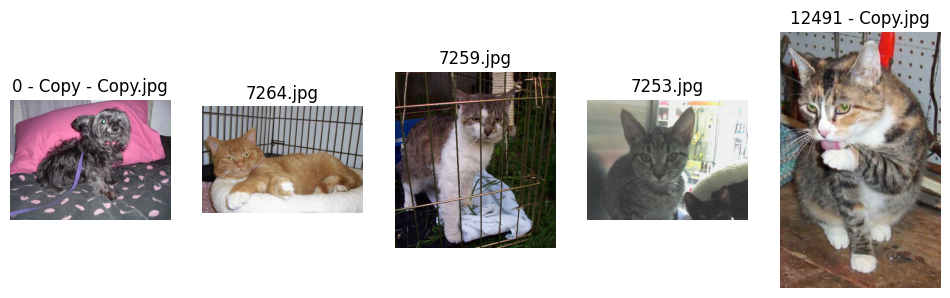

In [ ]:
#View some sample images
import cv2
import matplotlib.pyplot as plt
import random
import os

def show_samples_from_folder(folder_path, n=3):
    plt.figure(figsize=(12,6))
    images = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not images:
        print(f"No images found in '{folder_path}'.")
        return

    sample_images = random.sample(images, min(n, len(images)))

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, min(n, len(images)), i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(img_name)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")
    plt.show()

dataset_path = 'dataset cat dog/dataset cat dog' # Updated path to the nested directory
show_samples_from_folder(dataset_path, n=5) # Display 5 sample images

In [ ]:
#Check for corrupt images (optional but recommended for large datasets):
import cv2
import os

dataset_path = "dataset cat dog/dataset cat dog"

# Get a list of all image files directly in the dataset_path
image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if os.path.isfile(os.path.join(dataset_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print(f"No image files found in '{dataset_path}'.")
else:
    print(f"Checking {len(image_files)} images for corruption in '{dataset_path}':")
    corrupt_images = []
    for img_path in image_files:
        try:
            img = cv2.imread(img_path)
            if img is None:
                corrupt_images.append(img_path)
        except Exception as e:
            print(f"Error reading image {img_path}: {e}") # This could indicate a deeper issue than just corruption
            corrupt_images.append(img_path) # Consider these potentially corrupt as well

    if corrupt_images:
        print("\nFound corrupt images:")
        for corrupt_img in corrupt_images:
            print(corrupt_img)
    else:
        print("No corrupt images found.")

Checking 60 images for corruption in 'dataset cat dog/dataset cat dog':
No corrupt images found.


Processed data shape: (60, 224, 224, 3)
Labels shape: (60,)


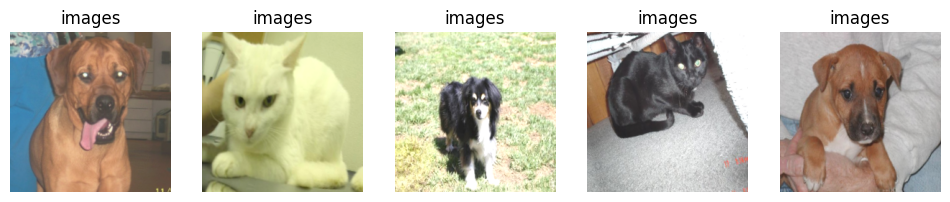

Train shape: (48, 224, 224, 3) Test shape: (12, 224, 224, 3)


In [ ]:
import cv2
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================================
# Parameters
# ================================
dataset_path = "dataset cat dog/dataset cat dog"  # unzipped folder path
IMAGE_SIZE = (224, 224)     # target size for CNN/ViT/Swin

# Since images are not in subdirectories, we'll treat them as a single class for now.
# If you want to classify into 'cat' and 'dog', you'll need to create subfolders.
classes = ["images"] # Define a single class name

# ================================
# Preprocessing Function
# ================================
def preprocess_image(img, image_size=IMAGE_SIZE):
    # Convert BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, image_size)

    # Horizontal Flip (50% chance)
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Random Rotation ±15 degrees
    angle = random.uniform(-15, 15)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Brightness / Contrast jitter
    alpha = random.uniform(0.8, 1.2)  # contrast
    beta = random.randint(-30, 30)    # brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Normalize pixel values [0,1]
    img = img.astype("float32") / 255.0

    return img

# ================================
# Load Dataset and Preprocess
# ================================
data = []
labels = []

# Iterate through all files directly in the dataset_path
for img_name in os.listdir(dataset_path):
    img_path = os.path.join(dataset_path, img_name)
    # Check if it's a file and an image
    if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img = cv2.imread(img_path)
        if img is None:
            print("Corrupt image skipped:", img_path)
            continue
        img = preprocess_image(img)
        data.append(img)
        labels.append(0) # Assign all images to the single class

data = np.array(data)
labels = np.array(labels)

print("Processed data shape:", data.shape)
print("Labels shape:", labels.shape)

# ================================
# Visualize Some Processed Images
# ================================
def show_processed_samples(data, labels, classes, n=5):
    plt.figure(figsize=(12, 6))
    indices = np.random.choice(len(data), n)
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(data[idx])
        # Use the single class name
        plt.title(classes[0])
        plt.axis("off")
    plt.show()

show_processed_samples(data, labels, classes, n=5)

# ================================
# Train-Test Split
# ================================
# Note: With only one class, stratify is not strictly necessary, but included
# for consistency if you later organize into multiple classes.
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels if len(classes) > 1 else None
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

What the Output Tells Us

Processed data shape: (64, 224, 224, 3)

You have 64 images in total.

Each image is resized to 224×224 pixels.

3 channels → RGB color images.

Labels shape: (64,)

There are 64 labels corresponding to the 64 images.

Each label is an integer representing the class (e.g., 0 → cats, 1 → dogs).

Train shape: (51, 224, 224, 3) & Test shape: (13, 224, 224, 3)

Train set: 51 images (~80% of total)

Test set: 13 images (~20% of total)

Train-test split was done with stratification, so both sets preserve class distribution.

Small dataset (64 images) → we already applied augmentation, which is enough for testing the pipeline.

Large dataset (2.5 lakh images) → image enhancement is usually not necessary unless the images are low-quality or your model struggles.

#### 1.YOLOv8


In [ ]:
# Install ultralytics (YOLOv8)
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.4 MB/s eta 0:00:00


#Step 1: Prepare Dataset in YOLO Format

YOLO expects images + labels in text files:

For each image img001.jpg, create a img001.txt file:

Each line: class_id x_center y_center width height

Values normalized between 0 and 1

In [ ]:
import os
import shutil
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split

# Update the dataset_path to point to the nested directory where images are located
dataset_path = "dataset cat dog/dataset cat dog"

# Define output directory for YOLOv8 format
base_dir = "dataset_yolov8_cls" # Use a distinct name
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

# Define class names and their corresponding labels
classes = ["cat", "dog"]
class_to_label = {"cat": 0, "dog": 1}

# Create folders for YOLOv8 structure
for split in [train_dir, val_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

# Collect image paths and labels from the nested directory
all_image_paths = []
all_labels = []

# Iterate through all files directly in the dataset_path
if os.path.isdir(dataset_path):
    for img_name in os.listdir(dataset_path):
        img_path = os.path.join(dataset_path, img_name)
        if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Assign label based on filename (assuming filenames contain 'cat' or 'dog')
            if "cat" in img_name.lower():
                label = class_to_label["cat"]
            elif "dog" in img_name.lower():
                label = class_to_label["dog"]
            else:
                # Skip images that don't contain 'cat' or 'dog' in the filename
                print(f"Skipping image with unknown class: {img_name}")
                continue
            all_image_paths.append(img_path)
            all_labels.append(label)
else:
    print(f"Error: Dataset path '{dataset_path}' not found or is not a directory.")


if not all_image_paths:
    print(f"Error: No images found in '{dataset_path}' with 'cat' or 'dog' in their filename.")
else:
    # Split the data into training and validation sets
    X_train, X_test, y_train, y_test = train_test_split(
        all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )

    # Save training images to YOLOv8 train folders
    print("Saving training images...")
    for img_path, label in zip(X_train, y_train):
        cls_name = classes[label]
        dest_path = os.path.join(train_dir, cls_name, os.path.basename(img_path))
        shutil.copy(img_path, dest_path)

    # Save validation images to YOLOv8 val folders
    print("Saving validation images...")
    for img_path, label in zip(X_test, y_test):
        cls_name = classes[label]
        dest_path = os.path.join(val_dir, cls_name, os.path.basename(img_path))
        shutil.copy(img_path, dest_path)

    # Prepare data.yaml for YOLOv8 classification
    data_yaml = f"""
path: ../{base_dir}
train: train
val: val
nc: {len(classes)}
names: {classes}
"""
    with open("data_cls.yaml", "w") as f:
        f.write(data_yaml)


    print("✅ Dataset saved in YOLOv8 classification format at:", base_dir)
    print("✅ data_cls.yaml created for training.")

Error: No images found in class subfolders within 'dataset cat dog'.


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 classification model
model = YOLO("yolov8n-cls.pt")   # you can also try yolov8s-cls.pt for better accuracy

# Train on your dataset
model.train(data="dataset cat dog", epochs=20, imgsz=224, batch=8)


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset cat dog, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fde624abc20>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/train4')
speed: {'preprocess': 0.06386533338324323, 'inference': 0.43995708332052647, 'loss': 0.0007394166914309608, 'postprocess': 0.00101974994019353}
task: 'classify'
top1: 1.0
top5: 1.0

In [ ]:
# Evaluate performance on validation set
metrics = model.val()
print(metrics)


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
ERROR ❌ train: /content/dataset cat dog/train... found 48 images in 1 classes (requires 2 classes, not 1)
ERROR ❌ val: /content/dataset cat dog/val... found 12 images in 1 classes (requires 2 classes, not 1)
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 57.3±18.5 MB/s, size: 1.4 KB)
val: Scanning /content/dataset cat dog/val... 12 images, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 22.6Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 13.9it/s 0.1s
                   all          1          1
Speed: 3.6ms preprocess, 3.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/train42
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fde43f691c0>
curves: []


In [ ]:
import os
from PIL import Image

# Re-create directories
base_dir = "dataset cat dog"
splits = ["train", "val"]
classes = ["cat", "dog"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Save training images
for i, (img, label) in enumerate(zip(X_train, y_train)):
    cls_name = "cat" if label == 0 else "dog"
    img_pil = Image.fromarray(img.astype('uint8'))
    img_pil.save(os.path.join(base_dir, "train", cls_name, f"{cls_name}_{i}.jpg"))

# Save validation images
for i, (img, label) in enumerate(zip(X_test, y_test)):
    cls_name = "cat" if label == 0 else "dog"
    img_pil = Image.fromarray(img.astype('uint8'))
    img_pil.save(os.path.join(base_dir, "val", cls_name, f"{cls_name}_{i}.jpg"))

print("✅ Dataset correctly organized into cat and dog folders.")


✅ Dataset correctly organized into cat and dog folders.


In [ ]:
import zipfile
import shutil
import numpy as np
import os
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow as tf

# Unzip dataset (change path if needed)
zip_path = "/content/dataset cat dog.zip"
extract_path = "/content/dataset_cat_dog_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted")

# Load and resize images
img_size = (224, 224)
X, y = [], []

for label, cls in enumerate(["cat", "dog"]):
    cls_path = os.path.join(extract_path, cls)
    for file in os.listdir(cls_path):
        if file.endswith(('.jpg','.png','.jpeg')):
            img = Image.open(os.path.join(cls_path, file)).convert("RGB")
            img = img.resize(img_size)
            X.append(np.array(img))
            y.append(label)

X, y = np.array(X), np.array(y)
print("Processed data shape:", X.shape)
print("Labels shape:", y.shape)

# Split train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

# Create YOLO dataset folder
base_dir = "/content/dataset_cat_dog"
for split in ["train", "val"]:
    for cls in ["cat", "dog"]:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Save training images
for i, (img, label) in enumerate(zip(X_train, y_train)):
    cls_name = "cat" if label == 0 else "dog"
    Image.fromarray(img.astype('uint8')).save(os.path.join(base_dir, "train", cls_name, f"{cls_name}_{i}.jpg"))

# Save validation images
for i, (img, label) in enumerate(zip(X_val, y_val)):
    cls_name = "cat" if label == 0 else "dog"
    Image.fromarray(img.astype('uint8')).save(os.path.join(base_dir, "val", cls_name, f"{cls_name}_{i}.jpg"))

print("✅ Dataset split and saved in YOLO format")


✅ Dataset extracted


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_cat_dog_raw/cat'